In [97]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# MachineMoo Imports
from machinemoo.scalarization.examples.logistic_fair import FairLogRegMO
from machinemoo.scalarization.lipschitz_estimation import calculate_logreg_lipschitz_constant
from machinemoo.moo.core import MachineMoo, get_objectives, get_history_objectives
from machinemoo.moo.random_weights import RandomWeights
from machinemoo.moo.monise import MONISE
from machinemoo.moo.mola import MOLA
from machinemoo.moo.nise import NISE

# Utils
from machinemoo.analysis.decision import filter_dominated

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
# Load dataset
# Ensure the path is correct relative to your notebook
df = pd.read_csv('dataset/compas_onerace.csv')

# Drop unnamed index column if it exists
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

# Define features
fair_feature = 'not_white'
pred_feature = 'Two_yr_Recidivism'

print(f"Dataset loaded. Shape: {df.shape}")

# Preprocessing
X = df.drop([pred_feature], axis=1)
# Normalize target to 0/1 (if not already)
y = (df[pred_feature] + 1) // 2 

# Stratified split to maintain class/group balance
# Create a stratification key based on target + sensitive attribute
stratify_col = y.astype(str) + "_" + X[fair_feature].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, # As per your original notebook
    stratify=stratify_col,
)

# Scaling is important for Logistic Regression convergence
scaler = StandardScaler()
# Keep as DataFrames to preserve column names for LogRegScalarization
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
# Restore the binary sensitive feature to 0/1 (scaling might have shifted it)
# This is crucial because LogRegScalarization uses unique values of fair_feat
X_train[fair_feature] = X.loc[X_train.index, fair_feature]

X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)
X_test[fair_feature] = X.loc[X_test.index, fair_feature]

print(f"Training set size: {len(X_train)}")

Dataset loaded. Shape: (6172, 7)
Training set size: 4320


In [87]:
common_opt_params = {
    'target_size': 10000000000,
    'time_limit': 10, 
}
IP_opt_params={**common_opt_params, 'node_gap': 0.01, 'node_time_limit': 1.0}

scalarizer_zero = FairLogRegMO(
    num_objs=2, 
    X=X_train,
    y=y_train,
    fair_feat=fair_feature,
    max_iter=1,
    tol=1e-10, 
    lower_bound_estimate="zero"
)

scalarizer_lipschitz = FairLogRegMO(
    num_objs=2, 
    X=X_train,
    y=y_train,
    fair_feat=fair_feature,
    max_iter=3,
    tol=1e-10,
    lower_bound_estimate="lipschitz"
)

machine_moo_zero = MachineMoo(scalarizer_zero, scalarizer_zero)
machine_moo_lipschitz = MachineMoo(scalarizer_lipschitz, scalarizer_lipschitz)

common_scalarizer_params = {
    # Any common params can go here
    'max_iter': 1,
    'tol': 1e-4
}

results = {}
print("Running NISE...\n")
results['NISE'] = machine_moo_zero.run(NISE, common_opt_params)

print("Running NISE-Lip...\n")
results['NISE-Lip'] = machine_moo_lipschitz.run(NISE, common_opt_params)

print("Running Random Weights...\n")
results['RW-Lip'] = machine_moo_lipschitz.run(RandomWeights, common_opt_params)

print("Running MONISE...\n")
results['MONISE-Lip'] = machine_moo_lipschitz.run(MONISE, common_opt_params)

Running NISE...

Running NISE-Lip...

Running Random Weights...

Running MONISE...



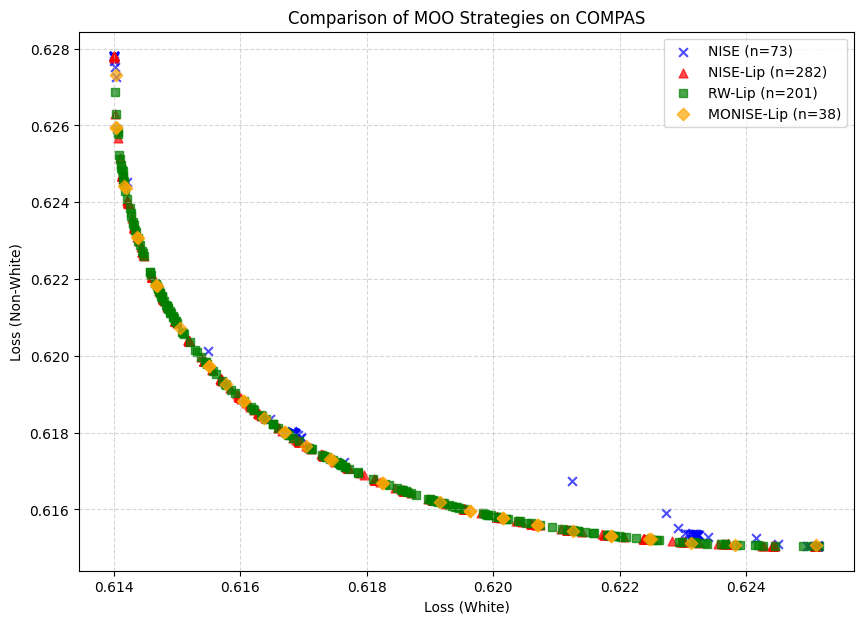


Runtime Comparison:
NISE: 10.01 s
NISE-Lip: 10.01 s
RW-Lip: 10.03 s
MONISE-Lip: 10.91 s


In [88]:
plt.figure(figsize=(10, 7))

#colors = {'RW': 'gray', 'Monise-Zero': 'blue', 'Monise-Lip': 'red', 'Mola-Zero': 'green', 'Mola-Lip': 'orange'}
#markers = {'RW': 'o', 'Monise-Zero': 'x', 'Monise-Lip': '^', 'Mola-Zero': 's', 'Mola-Lip': 'D'}
colors = {'RW': 'gray', 'NISE': 'blue', 'NISE-Lip': 'red', 'RW-Lip': 'green', 'MONISE-Lip': 'orange'}
markers = {'RW': 'o', 'NISE': 'x', 'NISE-Lip': '^', 'RW-Lip': 's', 'MONISE-Lip': 'D'}

for key, res in results.items():
    objs = get_objectives(res)
    plt.scatter(
        objs[:, 0], objs[:, 1], 
        label=f"{key} (n={len(objs)})", 
        c=colors[key], marker=markers[key], s=40, alpha=0.7 
    )

plt.xlabel('Loss (White)')
plt.ylabel('Loss (Non-White)')
plt.title('Comparison of MOO Strategies on COMPAS')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# Print Runtimes
print("\nRuntime Comparison:")
for key, res in results.items():
    print(f"{key}: {res.fit_runtime:.2f} s")

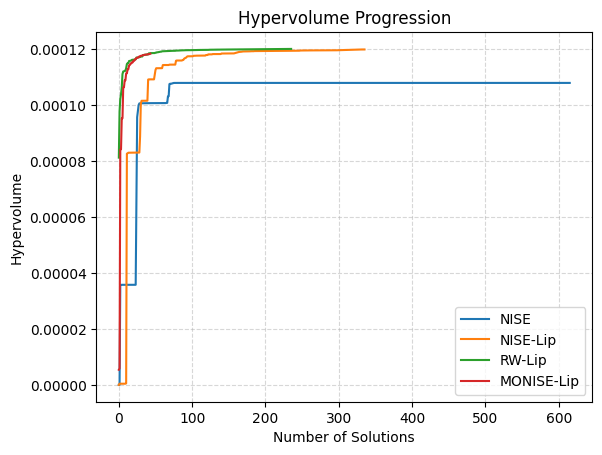

In [98]:
from machinemoo.analysis.metrics import compute_hypervolume_progress

reference_point = np.array([-np.inf, -np.inf])  # Adjust based on your objective scales
for key, res in results.items():
    objs = get_objectives(res)
    reference_point = np.maximum(reference_point, objs.max(axis=0))

for key, res in results.items():
    objs = get_history_objectives(res)
    hv_values = compute_hypervolume_progress(objs, reference_point)
    plt.plot(hv_values, label=key)

plt.xlabel('Number of Solutions')
plt.ylabel('Hypervolume')
plt.title('Hypervolume Progression')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()